# CLUSTERING ANALYSIS 

In [5]:
import pandas as pd
df=pd.read_excel("C:\\Users\\ASUS\\OneDrive\\Desktop\\ExcelR assignments\\8\\Clustering\\EastWestAirlines.xlsx",sheet_name="data")
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [ ]:
Data Preprocessing:

In [7]:
print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [23]:
df.fillna(df.mean(),inplace=True)
for column in df.select_dtypes(include=["number"]).columns:
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[column]>=lower_bound)&(df[column]<=upper_bound)]
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numerical_features=df.select_dtypes(include=["number"]).columns
df[numerical_features]=scaler.fit_transform(df[numerical_features])
print(df)

           ID#   Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
0    -2.006344  0.741624         0.0        0.0        0.0        0.0   
1    -2.005497  0.099834         0.0        0.0        0.0        0.0   
3    -2.003801 -0.222395         0.0        0.0        0.0        0.0   
5    -2.002106 -0.103831         0.0        0.0        0.0        0.0   
14   -1.994476 -0.015268         0.0        0.0        0.0        0.0   
...        ...       ...         ...        ...        ...        ...   
3983  1.388816  0.599549         0.0        0.0        0.0        0.0   
3984  1.389664 -1.258893         0.0        0.0        0.0        0.0   
3988  1.393055 -0.927433         0.0        0.0        0.0        0.0   
3993  1.397294 -1.001427         0.0        0.0        0.0        0.0   
3998  1.401532 -1.070517         0.0        0.0        0.0        0.0   

      Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
0       -0.492889    -0.400740                0.0    

                ID#       Balance  Qual_miles  cc1_miles  cc2_miles  \
count  8.560000e+02  8.560000e+02       856.0      856.0      856.0   
mean   1.328117e-16 -6.640586e-17         0.0        0.0        0.0   
std    1.000585e+00  1.000585e+00         0.0        0.0        0.0   
min   -2.006344e+00 -1.283125e+00         0.0        0.0        0.0   
25%   -8.199455e-01 -8.313337e-01         0.0        0.0        0.0   
50%    1.354467e-01 -1.966120e-01         0.0        0.0        0.0   
75%    9.416384e-01  5.665721e-01         0.0        0.0        0.0   
max    1.401532e+00  2.927486e+00         0.0        0.0        0.0   

       cc3_miles   Bonus_miles   Bonus_trans  Flight_miles_12mo  \
count      856.0  8.560000e+02  8.560000e+02              856.0   
mean         0.0  5.810513e-17 -3.216534e-17                0.0   
std          0.0  1.000585e+00  1.000585e+00                0.0   
min          0.0 -7.254175e-01 -7.576945e-01                0.0   
25%          0.0 -7.25417

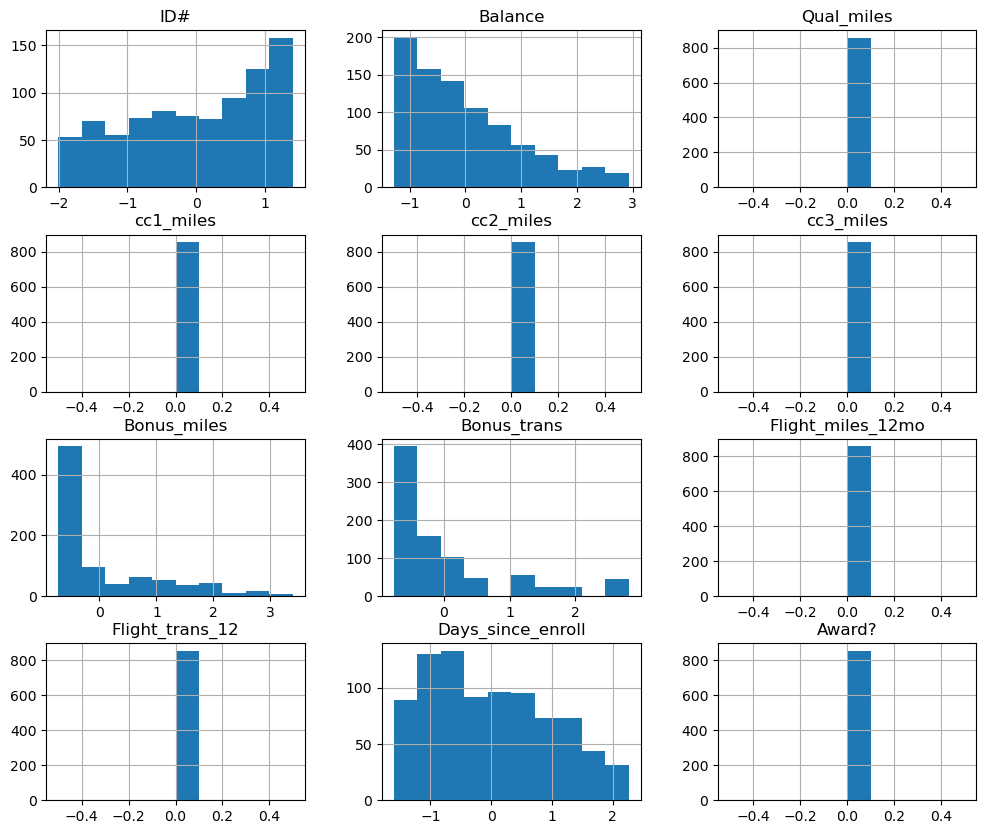

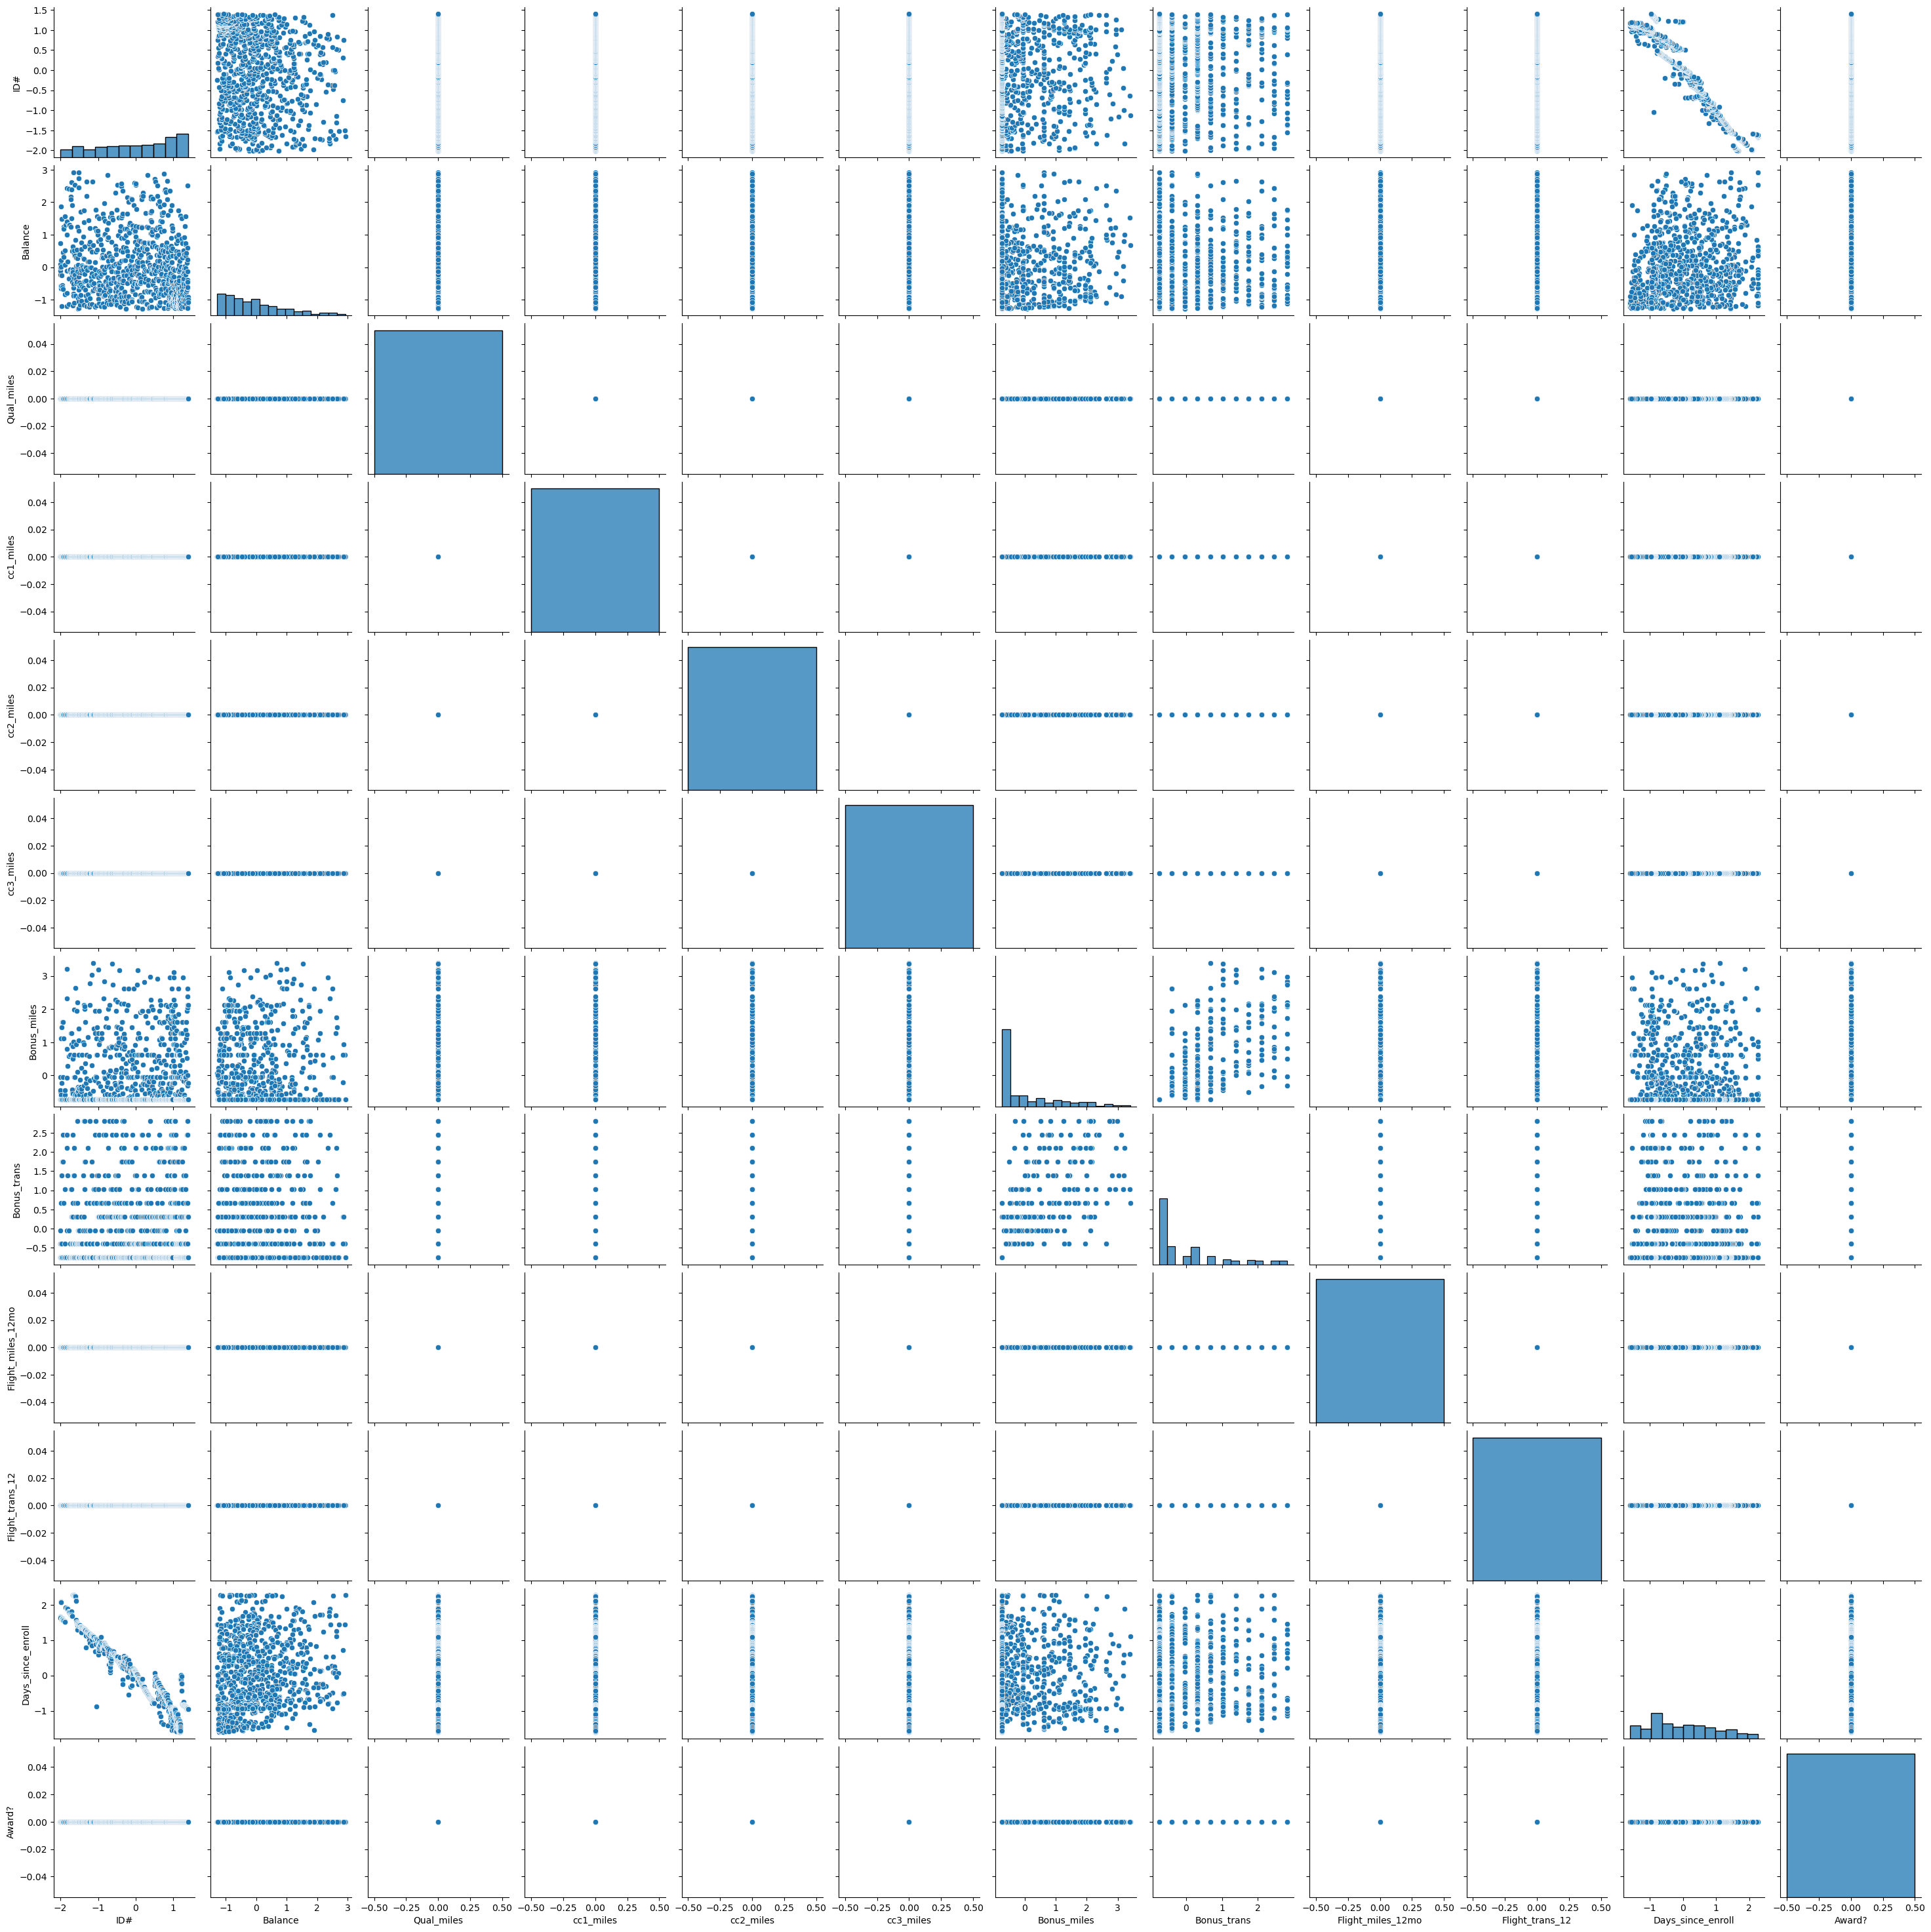

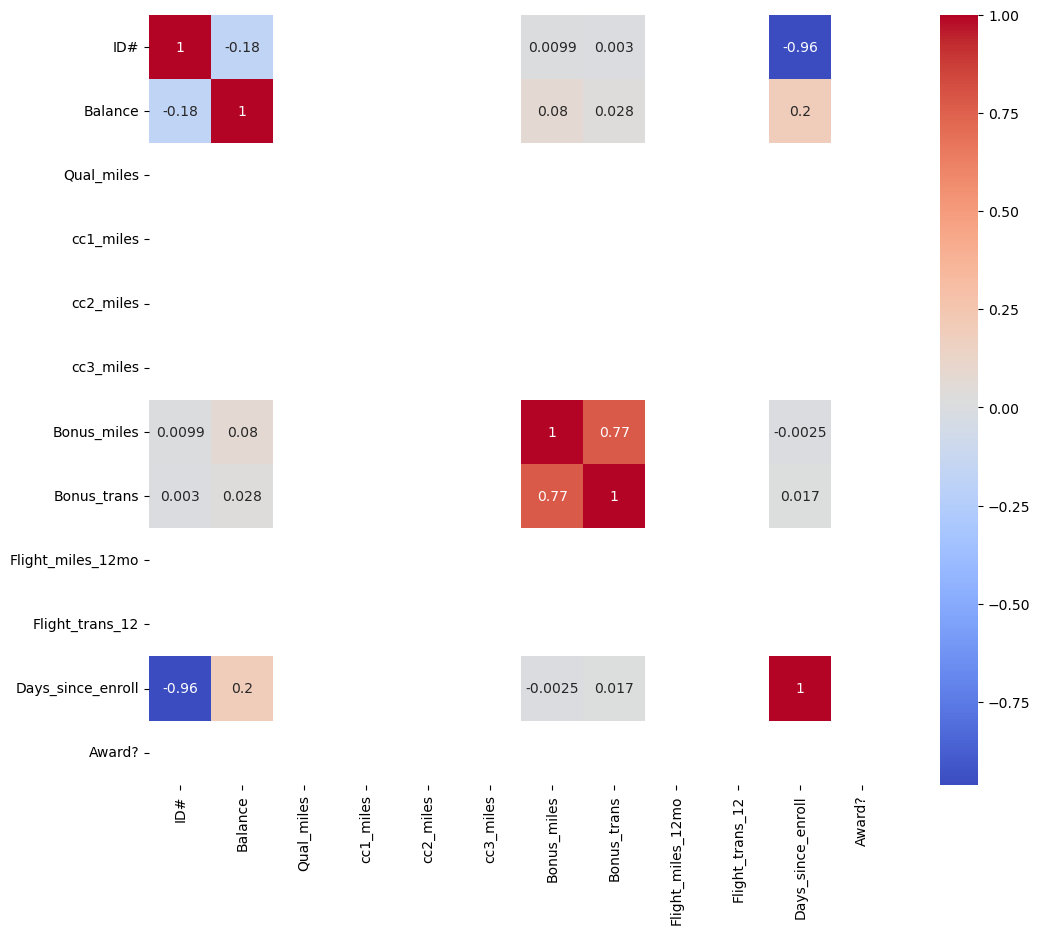

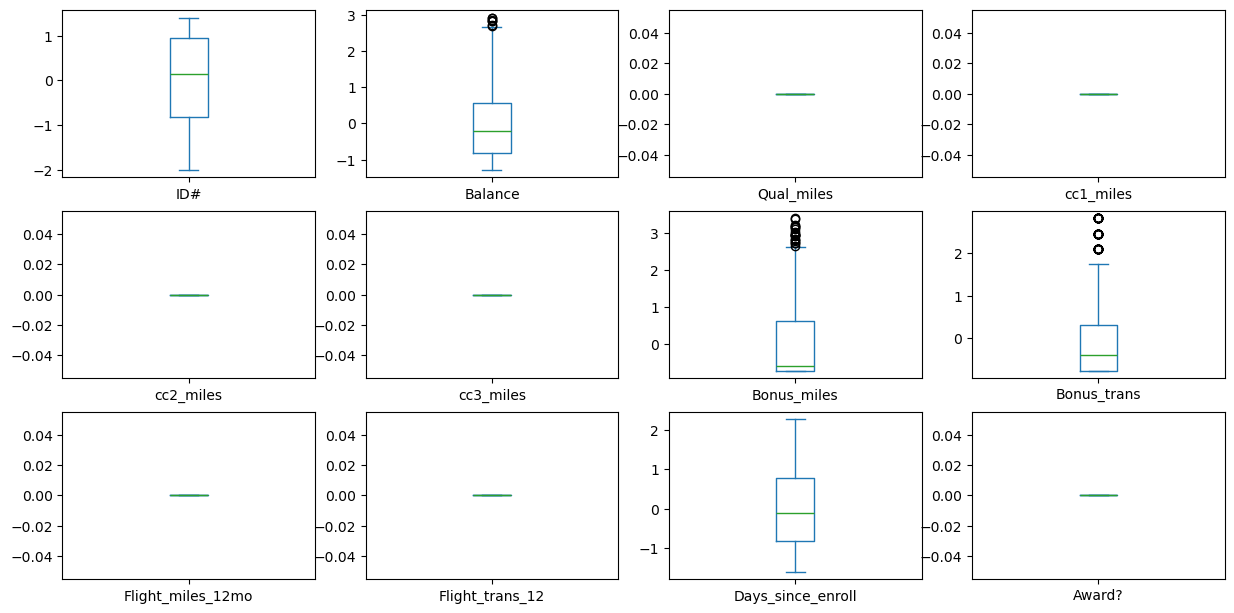

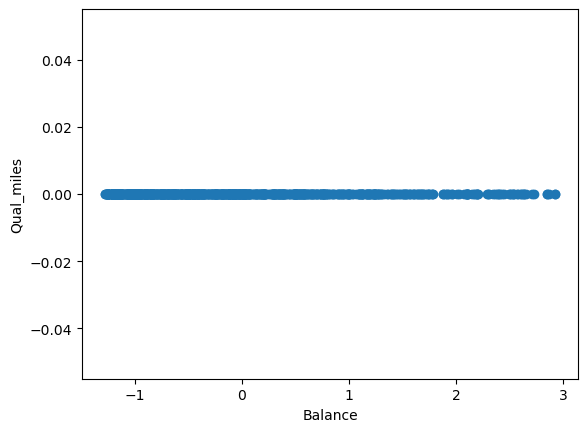

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df.describe())
df.hist(figsize=(12, 10))
plt.show()
sns.pairplot(df)
plt.show()
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()
df.plot(kind='box', subplots=True, layout=(4, 4), figsize=(15, 10))
plt.show()
plt.scatter(df['Balance'], df['Qual_miles'])
plt.xlabel('Balance')
plt.ylabel('Qual_miles')
plt.show()

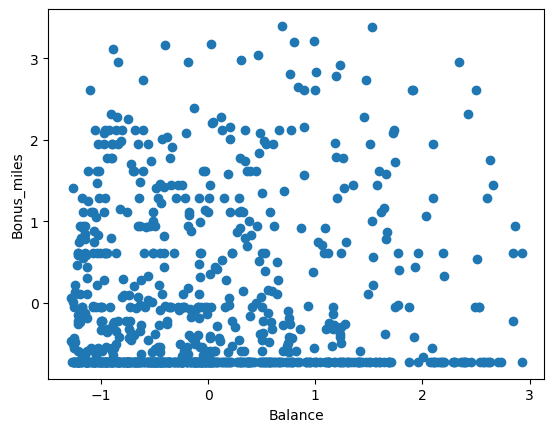

In [27]:
plt.scatter(df['Balance'], df['Bonus_miles'])
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.show()

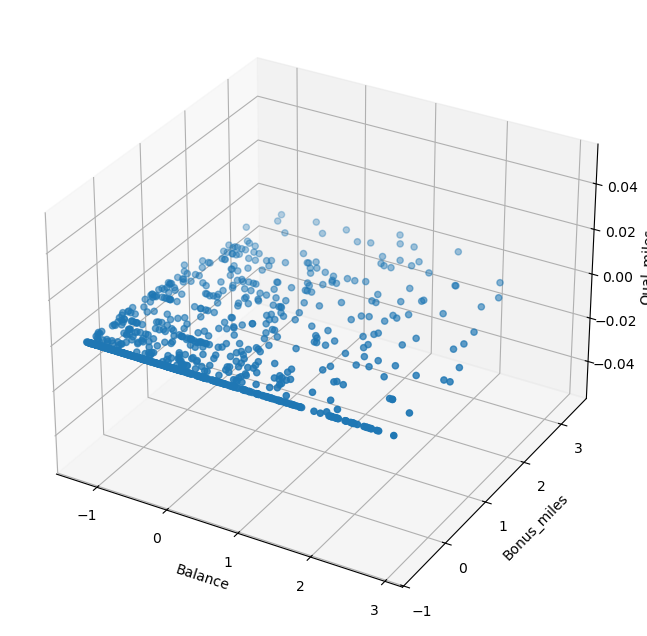

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Balance'], df['Bonus_miles'], df['Qual_miles'])
ax.set_xlabel('Balance')
ax.set_ylabel('Bonus_miles')
ax.set_zlabel('Qual_miles')
plt.show()

In [ ]:
Implementing Clustering Algorithms:

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


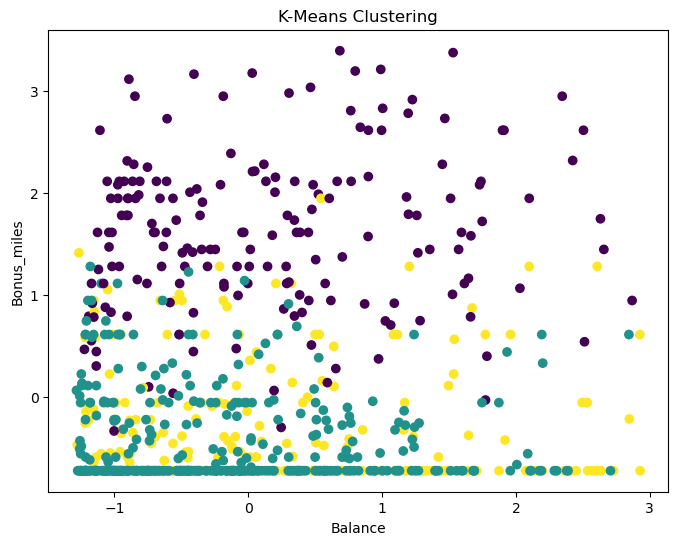

In [31]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Choose the number of clusters (n_clusters)
df['kmeans_cluster'] = kmeans.fit_predict(df[numerical_features])

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)  # Choose the number of clusters (n_clusters)
df['hierarchical_cluster'] = hierarchical.fit_predict(df[numerical_features])

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples as needed
df['dbscan_cluster'] = dbscan.fit_predict(df[numerical_features])


# Visualize the clusters using scatter plots (example with K-Means)
plt.figure(figsize=(8, 6))
plt.scatter(df['Balance'], df['Bonus_miles'], c=df['kmeans_cluster'], cmap='viridis')
plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.title('K-Means Clustering')
plt.show()

Linkage: ward, Silhouette Score: 0.2936704871451501
Linkage: complete, Silhouette Score: 0.18763146786522375
Linkage: average, Silhouette Score: 0.27505586571387564
Linkage: single, Silhouette Score: 0.24455901978091468


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

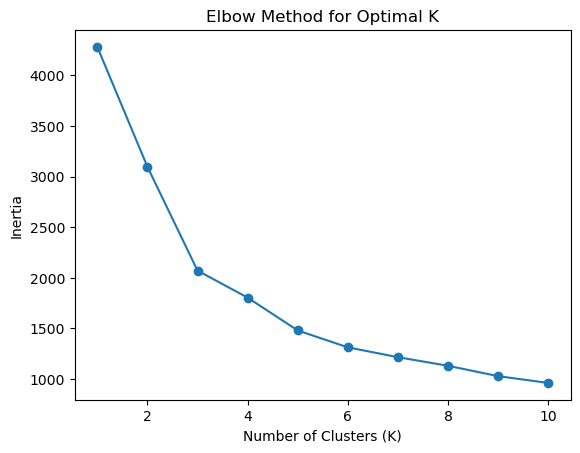

Epsilon: 0.5, MinPts: 5, Silhouette Score: -0.2537519304456714
Epsilon: 0.5, MinPts: 10, Silhouette Score: -0.15257447423534215
Epsilon: 0.5, MinPts: 15, Silhouette Score: 0.14541877771541778
Epsilon: 1, MinPts: 5, Silhouette Score: 0.2070125763970196
Epsilon: 1, MinPts: 10, Silhouette Score: 0.30248817650500626
Epsilon: 1, MinPts: 15, Silhouette Score: 0.3036889151092816
Epsilon: 1.5, MinPts: 5, Silhouette Score: 0.29763691645779033
Epsilon: 1.5, MinPts: 10, Silhouette Score: 0.35408597172910283
Epsilon: 1.5, MinPts: 15, Silhouette Score: 0.3495981509204646


In [33]:
# Experiment with different parameter settings for hierarchical clustering
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Iterate through different linkage criteria
linkage_criteria = ['ward', 'complete', 'average', 'single']
for linkage in linkage_criteria:
    hierarchical = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    df['hierarchical_cluster'] = hierarchical.fit_predict(df[numerical_features])
    silhouette_avg = silhouette_score(df[numerical_features], df['hierarchical_cluster'])
    print(f"Linkage: {linkage}, Silhouette Score: {silhouette_avg}")

# Experiment with different K values for K-means and plot the Elbow curve
from sklearn.cluster import KMeans
inertias = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df[numerical_features])
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


# Experiment with different epsilon and minPts values for DBSCAN
from sklearn.cluster import DBSCAN
eps_values = [0.5, 1, 1.5]
minPts_values = [5, 10, 15]

for eps in eps_values:
    for minPts in minPts_values:
        dbscan = DBSCAN(eps=eps, min_samples=minPts)
        df['dbscan_cluster'] = dbscan.fit_predict(df[numerical_features])
        # Evaluate the clustering results (e.g., using silhouette score if possible)
        try:
            silhouette_avg = silhouette_score(df[numerical_features], df['dbscan_cluster'])
            print(f"Epsilon: {eps}, MinPts: {minPts}, Silhouette Score: {silhouette_avg}")
        except ValueError:
            print(f"Epsilon: {eps}, MinPts: {minPts}, Silhoutte Score Cannot be calculated")

In [ ]:
Cluster Analysis and Interpretation:

In [35]:
# Analyze K-Means Clusters
for cluster_id in df['kmeans_cluster'].unique():
  print(f"K-Means Cluster {cluster_id}:")
  cluster_data = df[df['kmeans_cluster'] == cluster_id]
  print(cluster_data.describe())
  # Add our insights here based on the statistics. For example:
  # # Insight: Cluster 0 has a lower average balance and fewer bonus miles, indicating a potential group of less active or budget-conscious customers.

# Analyze Hierarchical Clusters
for cluster_id in df['hierarchical_cluster'].unique():
  print(f"Hierarchical Cluster {cluster_id}:")
  cluster_data = df[df['hierarchical_cluster'] == cluster_id]
  print(cluster_data.describe())
  # Add our insights here based on the statistics. For example:
    # Analyze DBSCAN Clusters
for cluster_id in df['dbscan_cluster'].unique():
  if cluster_id != -1: # Exclude noise points (-1)
    print(f"DBSCAN Cluster {cluster_id}:")
    cluster_data = df[df['dbscan_cluster'] == cluster_id]
    print(cluster_data.describe())
    # Add our insights here based on the statistics. For example:
    # # Insight: Cluster 2 has a distinct characteristic of higher frequent flyer miles, suggesting a group of frequent travelers.

# Additional Insights:
# We might also consider:
# - Visualizing the clusters in different dimensions to identify key differentiating features
# - Comparing the cluster characteristics across different algorithms
# - Exploring the relationships between clusters and other variables (e.g., customer demographics, if available)

K-Means Cluster 2:
              ID#     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
count  286.000000  286.000000       286.0      286.0      286.0      286.0   
mean    -1.062900    0.154948         0.0        0.0        0.0        0.0   
std      0.550593    1.062747         0.0        0.0        0.0        0.0   
min     -2.006344   -1.277355         0.0        0.0        0.0        0.0   
25%     -1.532463   -0.656120         0.0        0.0        0.0        0.0   
50%     -1.033150   -0.118615         0.0        0.0        0.0        0.0   
75%     -0.596357    0.774420         0.0        0.0        0.0        0.0   
max      0.005320    2.927486         0.0        0.0        0.0        0.0   

       Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
count   286.000000   286.000000              286.0            286.0   
mean     -0.398801    -0.395748                0.0              0.0   
std       0.541064     0.556194                0.0              0

In [ ]:
Visualization: